In [ ]:
import pandas as pd
from sklearn.cluster import KMeans, MiniBatchKMeans, MeanShift, SpectralClustering
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    make_scorer, silhouette_score, davies_bouldin_score, calinski_harabasz_score
)

# df = pd.read_csv("../data/interim/wildfire_natural_reclassified.csv")
df = pd.read_csv("../data/interim/wildfire_natural_reassigned.csv")
df1 = df[df.CAUSE_CLASS == "Natural"][['FIRE_SIZE', 'LATITUDE', 'LONGITUDE']].sample(n=10000)

# param_grid = [{'clt': [MeanShift(), BayesianGaussianMixture()]}]

# def silhouette_scoring(estimator, X, y=None):
#     labels = estimator.fit_predict(X)
#     return silhouette_score(X, labels)

# def davies_bouldin_scoring(estimator, X, y=None):
#     labels = estimator.fit_predict(X)
#     # Since lower is better for DB, you might want to return its negative
#     return davies_bouldin_score(X, labels)

# def calinski_harabasz_scoring(estimator, X, y=None):
#     labels = estimator.fit_predict(X)
#     return calinski_harabasz_score(X, labels)

# funcs = [silhouette_scoring, davies_bouldin_scoring, calinski_harabasz_scoring]
# score_grid = {str(func).rsplit('_', 1)[0]: make_scorer(func) for func in funcs}

# pipeline = Pipeline([('std', StandardScaler()),('clt', MeanShift())])

# search = GridSearchCV(pipeline, param_grid, scoring=score_grid, refit=False)
# search.fit(df)

# search.cv_results_

/tmp/ipykernel_2713792/3757648837.py:12: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/wildfire_natural_reassigned.csv")


In [ ]:
import numpy as np
x_train, x_test = train_test_split(df1, random_state=37)[:2]


8 0.5782371862660683 0.5199071293092064 1228.025358716439
13


In [42]:
max = [[0,0, None],[0,0, None],[0,0, None]]


In [56]:
def cluster(clt):
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)

    clt.fit(x_train_scaled)
    ms_pred = clt.predict(x_test_scaled)
    
    # if metric == "internal":
    l = len(np.unique(ms_pred))
    s = silhouette_score(x_test_scaled, ms_pred)
    d = davies_bouldin_score(x_test_scaled, ms_pred)
    c = calinski_harabasz_score(x_test_scaled, ms_pred)
    if max[0][1] < s:
        max[0] = [l, s, clt]
    if max[1][1] > d:
        max[1] = [l, d, clt]
    if max[2][1] < c:
        max[2] = [l, c, clt]
        
    print(len(np.unique(ms_pred)), s, d, c)



In [66]:
    # else:
    #     print()

cluster(MeanShift())
print(len(df[df.CAUSE_CLASS == "Human"].CAUSE.value_counts()))



8 0.5782371862660683 0.5199071293092064 1228.025358716439
13


In [ ]:
# cluster(BayesianGaussianMixture(), metric='internal')

max = [[0,0, None],[0,10, None],[0,0, None]]
for i in range(2,50):
    cluster(KMeans(i, random_state=37))
    cluster(GaussianMixture(i, random_state=37))
    # cluster(SpectralClustering(i))
    # cluster(MiniBatchKMeans(i, random_state=37))

print(f"Final: {max}")

2 0.391250006085746 1.0655840790366398 974.3407370524925
3 0.42660909132709257 0.9119278548132908 1020.6097661459556
4 0.43282121839030696 0.6810077552186177 1442.5546634867333
5 0.44461380086275276 0.6287471033841311 1257.5174979592691
6 0.4629203247285101 0.5931808668153243 1322.717914683863
7 0.5184994111382257 0.45202782962372784 2797.8933346184317
8 0.42875048249093106 0.5498608241067714 2087.708738443538
9 0.4626212612899787 0.518135573421662 2972.812051139429
9 0.46960873487232446 0.5921579944599326 3337.8160904207907
10 0.4815173352655236 0.561036806863758 3757.501296558752
10 0.4815173352655236 0.561036806863758 3757.501296558752
11 0.46639667323211303 0.5833617175984488 3950.64290383739
12 0.45584479531255284 0.6111323480552954 4251.910476974396
13 0.4499657239839899 0.6236235890934625 4293.10050919401
14 0.4550204601272206 0.6084672687097009 4530.596567333218
15 0.4520461095954083 0.6079497038524149 4735.787274897443
16 0.4548522080327123 0.6313977530830386 4917.518784838569

In [64]:
max1 = max
max1

[[8, 0.35054309545901724, GaussianMixture(n_components=8, random_state=37)],
 [7, 1.53184438987407, GaussianMixture(n_components=7, random_state=37)],
 [10, 1252.5922724344764, GaussianMixture(n_components=10, random_state=37)]]

In [69]:
# so bascially kmeans n=7
for i in range(2,50):
    cluster(KMeans(i, random_state=37))
    cluster(GaussianMixture(i, random_state=37))
    cluster(MiniBatchKMeans(i, random_state=37))

2 0.391250006085746 1.0655840790366398 974.3407370524925
2 0.19578911184016295 5.549476150939552 22.749261490898167
2 0.48718918513473725 0.7507163344858414 1092.0124368373984
3 0.42660909132709257 0.9119278548132908 1020.6097661459556
3 0.31977150058105663 3.465389140457136 415.2435902104861
3 0.42580444371744597 0.9349904305936505 1016.9825391664507
4 0.43282121839030696 0.6810077552186177 1442.5546634867333
4 0.25022327622747237 4.1006900773874895 286.2580427986325
4 0.36954155180345516 0.9536587325051818 768.4313346207248
5 0.44461380086275276 0.6287471033841311 1257.5174979592691
5 0.1453504233614703 2.6967698717565143 219.95874033926816
5 0.33235237306372784 1.1330974612366085 769.8006318023513
6 0.4629203247285101 0.5931808668153243 1322.717914683863
6 0.21349716849713818 2.6409328723279906 269.48120251247315
6 0.39143215913494817 0.9015927056896231 929.1724639736201
7 0.5184994111382257 0.45202782962372784 2797.8933346184317
7 0.25343170458884634 1.53184438987407 490.6854787900

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn_genetic import GAFeatureSelectionCV
from sklearn_genetic.space import Integer, Continuous
from sklearn.metrics import silhouette_score, make_scorer
from sklearn.model_selection import train_test_split
import numpy as np

df = pd.read_csv("../data/interim/wildfire_natural_reassigned.csv")
df1 = df[df.CAUSE_CLASS == "Natural"][['FIRE_SIZE', 'LATITUDE', 'LONGITUDE']].sample(n=10000)
x_train, x_test = train_test_split(df1, random_state=37)[:2]

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=7, random_state=37))
])

param_grid = {
    'init': ['k-means++', 'random'],
    'n_init': range(5,20),
    'max_iter': range(100, 500),
    'tol': np.logspace(-6, -2)
}
def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    # Check for single cluster
    # if len(set(labels)) < 2:
    #     return -1  # penalize single-cluster solutions
    return silhouette_score(X, labels)

scorer = make_scorer(silhouette_scorer, greater_is_better=True)

from sklearn_genetic import GASearchCV
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

evolved_estimator = RandomizedSearchCV(
    # estimator=pipeline,
    estimator=KMeans(n_clusters=7, random_state=37),
    # cv=3,
    scoring=silhouette_score,
    # population_size=20,    # population size (individuals per generation)
    # generations=10,        # number of generations
    # crossover_probability=0.8,
    # mutation_probability=0.1,
    param_distributions=param_grid,
    n_iter=10
    # algorithm='eaMuPlusLambda',
    # n_jobs=-1,
    # verbose=True
)

evolved_estimator.fit(x_train)
import joblib


results_df = pd.DataFrame(evolved_estimator.cv_results_)
results_df.sort_values('mean_test_score', ascending=False).head()


/tmp/ipykernel_3065768/1343745736.py:11: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/wildfire_natural_reassigned.csv")
/home/hejoefs/anaconda3/envs/env/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/hejoefs/anaconda3/envs/env/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 980, in _score
    scores = scorer(estimator, X_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/hejoefs/anaconda3/envs/env/lib/python3.11/site-packages/sklearn/utils/_param_validation.py", line 203, in wrapper
    validate_parameter_constraints(
  File "/home/hejoefs/anaconda3/envs/env/lib/python3.11/site-packages/sklearn/utils/_param_validation.py", line 95, in va

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_tol,param_n_init,param_max_iter,param_init,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.291465,0.108507,0.000666,0.000046,0.000133,10,491,random,"{'tol': 0.00013257113655901082, 'n_init': 10, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,0.040235,0.027651,0.000709,0.000099,0.000091,7,122,k-means++,"{'tol': 9.102981779915228e-05, 'n_init': 7, 'm...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,0.116538,0.046985,0.000902,0.000601,0.000004,14,200,k-means++,"{'tol': 4.498432668969444e-06, 'n_init': 14, '...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,0.084028,0.076103,0.000696,0.000101,0.000052,8,390,k-means++,"{'tol': 5.1794746792312125e-05, 'n_init': 8, '...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,0.226275,0.069857,0.000687,0.000095,0.006866,16,294,random,"{'tol': 0.006866488450042998, 'n_init': 16, 'm...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [ ]:
from sklearn.metrics import silhouette_score as sc

df = pd.read_csv("../data/interim/wildfire_natural_reassigned.csv")
def cv_silhouette_scorer(estimator, X):
    estimator.fit(X)
    cluster_labels = estimator.labels_
    num_labels = len(set(cluster_labels))
    num_samples = len(X.index)
    if num_labels == 1 or num_labels == num_samples:
        return -1
    else:
        return sc(X, cluster_labels)

cv = [(slice(None), slice(None))]
gs = RandomizedSearchCV(n_iter=10, estimator=KMeans(), param_distributions=param_grid, 
                  scoring=cv_silhouette_scorer, cv=cv, n_jobs=-1)
df1 = df[df.CAUSE_CLASS == "Natural"][['FIRE_SIZE', 'LATITUDE', 'LONGITUDE']].sample(n=10000)
gs.fit(df1)

/tmp/ipykernel_3065768/985363205.py:3: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/wildfire_natural_reassigned.csv")


RandomizedSearchCV(cv=[(slice(None, None, None), slice(None, None, None))],
                   estimator=KMeans(), n_jobs=-1,
                   param_distributions={'init': ['k-means++', 'random'],
                                        'max_iter': range(100, 500),
                                        'n_init': range(5, 20),
                                        'tol': array([1.00000000e-06, 1.20679264e-06, 1.45634848e-06, 1.75751062e-06,
       2.12095089e-06, 2.55954792e-06, 3.08884360e-06, 3.72759372e-06,
       4.49843267e-06, 5.428...
       1.93069773e-04, 2.32995181e-04, 2.81176870e-04, 3.39322177e-04,
       4.09491506e-04, 4.94171336e-04, 5.96362332e-04, 7.19685673e-04,
       8.68511374e-04, 1.04811313e-03, 1.26485522e-03, 1.52641797e-03,
       1.84206997e-03, 2.22299648e-03, 2.68269580e-03, 3.23745754e-03,
       3.90693994e-03, 4.71486636e-03, 5.68986603e-03, 6.86648845e-03,
       8.28642773e-03, 1.00000000e-02])},
                   scoring=<function cv_silhouette_scorer at 0x7fb3431991c0>)

In [53]:
results_df = pd.DataFrame(grid_search.cv_results_)
# results_df.sort_values('mean_test_score', ascending=False).head()
results_df


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_kmeans__max_iter,param_kmeans__n_clusters,param_kmeans__n_init,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score
0,0.032514,0.008773,0.625736,0.051952,100,7,5,"{'kmeans__max_iter': 100, 'kmeans__n_clusters'...",-0.363765,-0.066150,-0.214958,0.148808,1
1,0.067441,0.003604,0.625021,0.157251,100,7,7,"{'kmeans__max_iter': 100, 'kmeans__n_clusters'...",-0.363765,-0.066150,-0.214958,0.148808,1
2,0.050688,0.007188,0.605884,0.164938,100,7,9,"{'kmeans__max_iter': 100, 'kmeans__n_clusters'...",-0.363765,-0.066150,-0.214958,0.148808,1
3,0.042970,0.004408,0.358580,0.036128,100,7,11,"{'kmeans__max_iter': 100, 'kmeans__n_clusters'...",-0.363765,-0.066150,-0.214958,0.148808,1
4,0.095646,0.035522,0.440706,0.013712,100,7,13,"{'kmeans__max_iter': 100, 'kmeans__n_clusters'...",-0.363765,-0.066224,-0.214995,0.148771,91
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.108168,0.013161,0.484113,0.012944,500,7,16,"{'kmeans__max_iter': 500, 'kmeans__n_clusters'...",-0.363765,-0.066150,-0.214958,0.148808,1
96,0.052290,0.003345,0.553403,0.096483,500,7,18,"{'kmeans__max_iter': 500, 'kmeans__n_clusters'...",-0.363765,-0.066150,-0.214958,0.148808,1
97,0.097758,0.038757,0.358685,0.032761,500,7,20,"{'kmeans__max_iter': 500, 'kmeans__n_clusters'...",-0.363765,-0.066150,-0.214958,0.148808,1
98,0.115380,0.040310,0.344512,0.034804,500,7,22,"{'kmeans__max_iter': 500, 'kmeans__n_clusters'...",-0.363765,-0.066150,-0.214958,0.148808,1


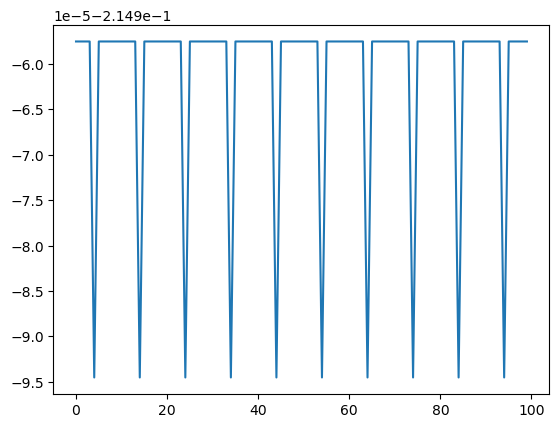

In [54]:
import matplotlib.pyplot as plt
plt.plot(results_df.mean_test_score)

In [79]:
df1 = df[df.CAUSE_CLASS == "Natural"][['FIRE_SIZE']].sample(n=10000)
x_train, x_test = train_test_split(df1, random_state=37)[:2]
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=7, random_state=37))
])

param_grid = {
    'kmeans__n_clusters': [7],
    # 'init': ['k-means++', 'random'],
    # 'kmeans__n_init': [5, 10, 17],
    'kmeans__n_init': range(1, 25),
    # 'kmeans__max_iter': [100, 200, 300, 400, 500],
    'kmeans__max_iter': [int(x) for x in np.logspace(1,3,10)],
    # 'tol': [0.0001, 0.001, 0.01],
    # 'algorithm': ['auto', 'full', 'elkan'],
    # 'random_state': [0, 42, 100]
}

# Create the KMeans object
kmeans = KMeans(random_state=42)

# Perform grid search
grid_search = GridSearchCV(pipeline, param_grid=param_grid, cv=2, n_jobs=-1, scoring=silhouette_scorer)
results_df = pd.DataFrame(evolved_estimator.cv_results_)
results_df.sort_values('mean_test_score', ascending=False).head()
# Fit the grid search to the data
grid_search.fit(x_train)

# Print the best hyperparameters
print("Best hyperparameters: ", grid_search.best_params_)
# print('Optimal number of clusters based on parameter grid: ' + str(grid_search.best_params_['n_clusters']))
import joblib
joblib.dump(grid_search.best_params_, "../models/best_kmeans_params.pkl")


Best hyperparameters:  {'kmeans__max_iter': 10, 'kmeans__n_clusters': 7, 'kmeans__n_init': 1}


['../models/best_kmeans_params.pkl']

In [78]:
results_df = pd.DataFrame(grid_search.cv_results_)
# results_df.sort_values('mean_test_score', ascending=False).head()
results_df.mean_test_score.value_counts()

mean_test_score
0.977825    170
0.977673     30
0.977684     20
0.979749     10
0.979684     10
Name: count, dtype: int64